In [85]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [49]:
# 필요 라이브러리 import
import numpy as np
import seaborn as sns # iris데이터
import pandas as pd # 원핫인코딩(get_dummies)
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from sklearn.preprocessing import MinMaxScaler, LabelEncoder # 스케일 조정, 라벨인코딩(문자->숫자)
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.model_selection import train_test_split # 층화추출 데이터 분할용
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt # 학습 과정 시각화
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score

- IRIS 데이터
1. sepal_length : 꽃받침 길이
2. sepal_width : 꽃받침 넓이
3. petal_length : 꽃잎 길이
4. petal_width : 꽃잎 넓이
5. species : 종 -> setosa, versicolor, virginica

In [10]:
# 문자형 변수의 원핫인코딩 방법1
iris = sns.load_dataset('iris')
iris.head(2) # species 종속변수 -> 문자형 데이터
# to_categorical(iris['species'])
labelEncoder = LabelEncoder()
# labelEncoder.fit(iris['species'])
# iris['y'] = labelEncoder.transform(iris['species'])
iris['y'] = labelEncoder.fit_transform(iris['species'])
# iris.tail(3)
to_categorical(iris['y'])[::25] # to_categorical의 결과 => numpy 배열

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.]], dtype=float32)

In [13]:
# 문자형 변수의 원핫인코딩 방법2
iris = sns.load_dataset('iris')
pd.get_dummies(iris.species).values # 결과 : DataFrame 
pd.get_dummies(iris.species).to_numpy()[::25]

array([[1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 0, 1]], dtype=uint8)

In [21]:
# 1. 데이터 생성 및 전처리
iris = sns.load_dataset('iris')
# iris.info() # 결측치 있으면 처리 우선
iris['species'].value_counts() # 데이터 균형 체크 : 타겟 변수의 분포
# 독립변수, 종속변수 분리
iris_X = iris.iloc[:,:-1].values
iris_y = iris.iloc[:,-1]
# iris_y # get_dummies를 사용하기 용이하게 Series로 처리
iris_Y = pd.get_dummies(iris_y).values # 원핫인코딩 완료
# 훈련셋, 테스트셋 8:2 분리
X_train, X_test, Y_train, Y_test = train_test_split(iris_X,iris_Y,
                                                    stratify=iris_Y, # 층화추출
                                                    test_size=0.2,# 데이터셋 비율 설정
                                                    random_state= 7, # 랜덤시드값
                                                    )
print(iris_X.shape, iris_Y.shape)
print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

(150, 4) (150, 3)
(120, 4) (120, 3)
(30, 4) (30, 3)


In [37]:
# 층화추출이 되었는 지 확인
print(pd.DataFrame(np.argmax(iris_Y, axis=1)).value_counts())
print(pd.DataFrame(np.argmax(Y_train, axis=1)).value_counts())
print(pd.DataFrame(np.argmax(Y_test, axis=1)).value_counts())

0    50
1    50
2    50
dtype: int64
0    40
1    40
2    40
dtype: int64
0    10
1    10
2    10
dtype: int64


In [46]:
# 2. 모델 구성(입력 4개, 출력 3개)
model = Sequential()
model.add(Dense(units=64, input_dim =4, activation = 'relu'))
model.add(Dense(units=128, activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(units=50, activation = 'relu'))
model.add(Dropout(0.1))
model.add(Dense(units=30, activation = 'relu'))
model.add(Dropout(0.1))
model.add(Dense(units=3, activation = 'softmax')) # 출력층
model.summary() # Total params: 16,713 => 1069632bit. 267408byte => 0.2MB

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 64)                320       
                                                                 
 dense_6 (Dense)             (None, 128)               8320      
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_7 (Dense)             (None, 50)                6450      
                                                                 
 dropout_1 (Dropout)         (None, 50)                0         
                                                                 
 dense_8 (Dense)             (None, 30)                1530      
                                                                 
 dropout_2 (Dropout)         (None, 30)               

In [47]:
# 3. 학습과정 설정
model.compile(loss='categorical_crossentropy', optimizer= 'adam', metrics=['accuracy'])
# 4. 학습 : epoch 마다 val_accuracy값이 좋아지고 있으면 model 자동 저장 : ModelCheckpoint(콜백추가) + EarlyStopping
    # 모델 자동 저장될 경로 ./model/iris-(epoch)-(val_accuracy).h5
import os
model_save_folder = './model_iris/'
if not os.path.exists(model_save_folder) : # 폴더가 루트에 없으면
    os.mkdir(model_save_folder)
file = model_save_folder + 'iris-{epoch:03d}-val{val_accuracy:.4f}.h5'
# 모델 자동 저장할 콜백 객체
checkpoint = ModelCheckpoint(filepath=file,
                             monitor = 'val_accuracy', # 모니터링 지표(기본값 : val_loss)
                             save_best_only=True, # False : 매번저장
#                              mode='max', # 자동으로 설정해준다
                             verbose = 1, # 모델 저장 시 로그 출력( 0: 로그X, 1: 간단로그, 2:상세로그)
                            )
# 조기종료 콜백 객체
earlystopping = EarlyStopping(patience=40) # monitor 기본값 : val_loss

# 학습
hist = model.fit(X_train,Y_train,
                batch_size=40,
                epochs=500,
                validation_split=0.2, # 훈련셋 20%를 검증셋으로 사용
                callbacks=[checkpoint, earlystopping])

Epoch 1/500
1/3 [=========>....................] - ETA: 1s - loss: 1.9236 - accuracy: 0.2750
Epoch 1: val_accuracy improved from -inf to 0.33333, saving model to ./model_iris\iris-001-val0.3333.h5
3/3 [==============================] - 1s 134ms/step - loss: 1.5571 - accuracy: 0.3438 - val_loss: 1.1416 - val_accuracy: 0.3333
Epoch 2/500
1/3 [=========>....................] - ETA: 0s - loss: 1.1760 - accuracy: 0.3500
Epoch 2: val_accuracy did not improve from 0.33333
3/3 [==============================] - 0s 14ms/step - loss: 1.1794 - accuracy: 0.3333 - val_loss: 1.1465 - val_accuracy: 0.2917
Epoch 3/500
1/3 [=========>....................] - ETA: 0s - loss: 0.9539 - accuracy: 0.5750
Epoch 3: val_accuracy did not improve from 0.33333
3/3 [==============================] - 0s 25ms/step - loss: 1.1160 - accuracy: 0.4167 - val_loss: 1.1555 - val_accuracy: 0.2917
Epoch 4/500
1/3 [=========>....................] - ETA: 0s - loss: 1.0075 - accuracy: 0.5500
Epoch 4: val_accuracy did not improve

Epoch 60/500
1/3 [=========>....................] - ETA: 0s - loss: 0.1742 - accuracy: 0.9500
Epoch 60: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 23ms/step - loss: 0.1327 - accuracy: 0.9688 - val_loss: 0.2151 - val_accuracy: 0.9167
Epoch 61/500
1/3 [=========>....................] - ETA: 0s - loss: 0.1199 - accuracy: 0.9750
Epoch 61: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 18ms/step - loss: 0.1942 - accuracy: 0.9271 - val_loss: 0.2165 - val_accuracy: 0.9167
Epoch 62/500
1/3 [=========>....................] - ETA: 0s - loss: 0.0950 - accuracy: 0.9500
Epoch 62: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 19ms/step - loss: 0.1054 - accuracy: 0.9688 - val_loss: 0.1854 - val_accuracy: 0.9583
Epoch 63/500
1/3 [=========>....................] - ETA: 0s - loss: 0.1201 - accuracy: 0.9500
Epoch 63: val_accuracy did not improve from 0.95833
3/3 [===========================

Epoch 90/500
1/3 [=========>....................] - ETA: 0s - loss: 0.0601 - accuracy: 0.9750
Epoch 90: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 18ms/step - loss: 0.1001 - accuracy: 0.9792 - val_loss: 0.1903 - val_accuracy: 0.9583
Epoch 91/500
1/3 [=========>....................] - ETA: 0s - loss: 0.1716 - accuracy: 0.9250
Epoch 91: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 17ms/step - loss: 0.0992 - accuracy: 0.9583 - val_loss: 0.2492 - val_accuracy: 0.9167
Epoch 92/500
1/3 [=========>....................] - ETA: 0s - loss: 0.0670 - accuracy: 0.9750
Epoch 92: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 18ms/step - loss: 0.0859 - accuracy: 0.9688 - val_loss: 0.2939 - val_accuracy: 0.9167
Epoch 93/500
1/3 [=========>....................] - ETA: 0s - loss: 0.2234 - accuracy: 0.9500
Epoch 93: val_accuracy did not improve from 0.95833
3/3 [===========================

Epoch 120/500
1/3 [=========>....................] - ETA: 0s - loss: 0.1511 - accuracy: 0.9500
Epoch 120: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 20ms/step - loss: 0.1103 - accuracy: 0.9479 - val_loss: 0.2142 - val_accuracy: 0.9583


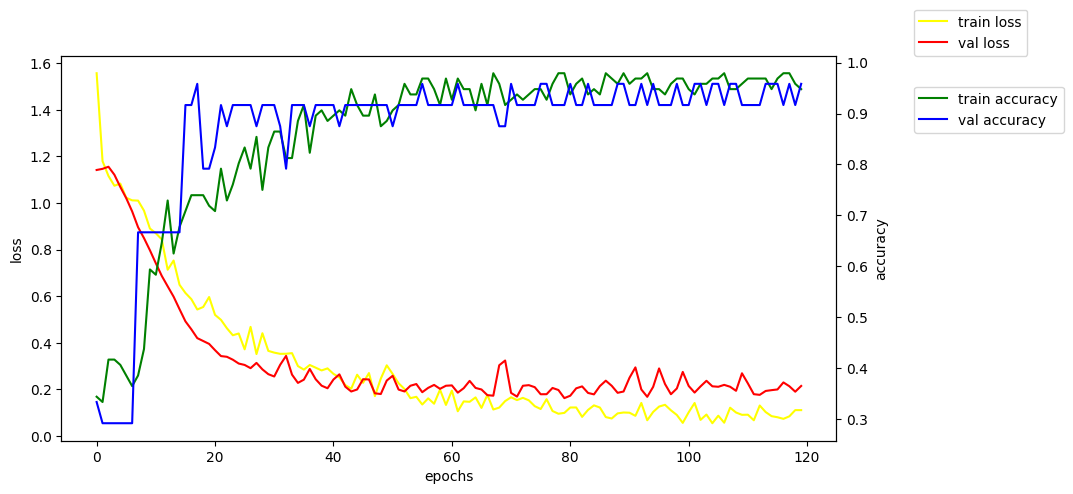

In [48]:
# hist.history.keys() # loss accuracy val_loss val_accuracy
fig, loss_ax = plt.subplots(figsize = (10,5))
loss_ax.plot(hist.history.get('loss'), color='yellow', label='train loss')
loss_ax.plot(hist.history.get('val_loss'), color='red', label='val loss')
loss_ax.legend(loc=(1.1,1))
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history.get('accuracy'), color='green', label='train accuracy')
acc_ax.plot(hist.history.get('val_accuracy'), color='blue', label='val accuracy')
acc_ax.legend(loc=(1.1,0.8))
acc_ax.set_ylabel('accuracy')
plt.show()

In [50]:
# 6. 모델 평가하기(evaluate : 테스트셋, [교차표, recall, precision] : y실제값, y예측값(y_hat))
# ModelCheckpoint에 의한 결과물 중 가장 accuracy가 높은 것 : iris-022-val0.9583.h5
# 현재모델과 accu가 높은 것을 같이 평가하여 실제 사용 모델을 사용
# recall과 precision, f1_score는  sklearn.metrics 라이브러리 활용
loss, acc = model.evaluate(X_test,Y_test)
loss, acc

1/1 [==============================] - 0s 26ms/step - loss: 0.0117 - accuracy: 1.0000


(0.011722182855010033, 1.0)

In [60]:
# 학습 완료 된 모델의 recall과 precision을 위해서 실제 값과 예측값을 계산
real = np.argmax(Y_test, axis=1)
pred = model.predict(X_test).argmax(axis=1)
recall = recall_score(real,pred,average='weighted') # average='weighted' : 다중분류
precision = precision_score(real,pred,average='weighted') # average='weighted' : 다중분류
f1 = f1_score(real, pred, average='weighted')
print('model accuracy :', acc)
print('model recall :', recall)
print('model precision :', precision)
print('model f1 score :', f1)
print('model loss :', loss)
# 좋은 결과 : 데이터의 수가 많거나, 데이터의 신뢰도가 높고 일관성이 있거나

1/1 [==============================] - 0s 34ms/step
model accuracy : 1.0
model recall : 1.0
model precision : 1.0
model f1 score : 1.0
model loss : 0.011722182855010033


In [61]:
# 저장된 모델로 체크
model2 = load_model('model_iris/iris-022-val0.9583.h5')
loss2, acc2 = model2.evaluate(X_test, Y_test)
pred2 = model2.predict(X_test).argmax(axis=1)
recall2 = recall_score(real,pred2,average='weighted') # average='weighted' : 다중분류
precision2 = precision_score(real,pred2,average='weighted') # average='weighted' : 다중분류
f12 = f1_score(real, pred2, average='weighted')
print('model2 accuracy :', acc2)
print('model2 recall :', recall2)
print('model2 precision :', precision2)
print('model2 f1 score :', f12)
print('model2 loss :', loss2)

1/1 [==============================] - 0s 79ms/step
model2 accuracy : 1.0
model2 recall : 1.0
model2 precision : 1.0
model2 f1 score : 1.0
model2 loss : 0.20871183276176453


In [62]:
# model(학습완료된 모델) Vs model2(중간 저장된 모델) => loss에서 차이 발생, loss가 작은 model이 더 효율적으로 판단
# 교차표 체크
pd.crosstab(real, pred, rownames=['실제값'],colnames=['예측값'])

예측값,0,1,2
실제값,,,
0,10,0,0
1,0,10,0
2,0,0,10


In [63]:
confusion_matrix(real,pred)

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  0, 10]], dtype=int64)

In [64]:
# 모델 저장 및 사용하기
save_model(model, 'model/iris.h5') # tensorflow 2.18 이상일 경우 확장자를 .keras 권장

In [70]:
# 모델 예측하기
print(model.predict(np.array([[4.8, 3.0, 1.4, 0.3]]),verbose=False).argmax(axis=1))
print(model.predict(np.array([[6.3, 3.3, 6.1, 2.4]]),verbose=False).argmax(axis=1))
# iris.iloc[45] setosa

[0]
[2]
